# Decision Tree Classification - Bank Marketing Campaign Prediction

## Business Problem

A Portuguese bank conducted direct marketing campaigns to promote term deposits.

The objective is to predict whether a customer will subscribe to a term deposit based on customer demographics, financial information and previous marketing campaign details.

### Target Variable

y

Values:
- yes
- no

## Process

1. Business Problem

2. Dataset Overview

3. Import Libraries

4. Load Dataset

5. Exploratory Data Analysis

6. Data Cleaning

7. Feature Engineering

8. Model Building

9. Model Evaluation

10. Business Insights

11. Conclusion

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("datasets/bank.csv")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [6]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [7]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873


In [8]:
df['deposit'].value_counts()

no     5873
yes    5289
Name: deposit, dtype: int64

In [9]:
df['deposit'].value_counts(normalize=True)

no     0.52616
yes    0.47384
Name: deposit, dtype: float64

In [10]:
df.head().T

,0,1,2,3,4
age,59,56,41,55,54
job,admin.,admin.,technician,services,admin.
marital,married,married,married,married,married
education,secondary,secondary,secondary,secondary,tertiary
default,no,no,no,no,no
balance,2343,45,1270,2476,184
housing,yes,no,yes,yes,no
loan,no,no,no,no,no
contact,unknown,unknown,unknown,unknown,unknown
day,5,5,5,5,5


In [11]:
df.nunique()

age            76
job            12
marital         3
education       4
default         2
balance      3805
housing         2
loan            2
contact         3
day            31
month          12
duration     1428
campaign       36
pdays         472
previous       34
poutcome        4
deposit         2
dtype: int64

In [12]:
# Checking unique values for categorical columns 

for col in df.select_dtypes(include='object').columns:
    print(col)
    print(df[col].value_counts())
    print("-"*50)

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: job, dtype: int64
--------------------------------------------------
marital
married     6351
single      3518
divorced    1293
Name: marital, dtype: int64
--------------------------------------------------
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: education, dtype: int64
--------------------------------------------------
default
no     10994
yes      168
Name: default, dtype: int64
--------------------------------------------------
housing
no     5881
yes    5281
Name: housing, dtype: int64
--------------------------------------------------
loan
no     9702
yes    1460
Name: loan, dtype: int64
--------------------------------------------------
contact
cellular     8042
u

#### choosing Decision Trees instead of Logistic Regression?


#### Decision Trees:

Capture non-linear relationships.
Handle categorical variables well (after encoding).
Don't require feature scaling.
Can model complex interactions between features.

#### Logistic Regression:

Assumes a linear relationship.
Requires scaling for better optimization.
Simpler and more interpretable.

In [13]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
numerical_cols

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

### Univariate analysis

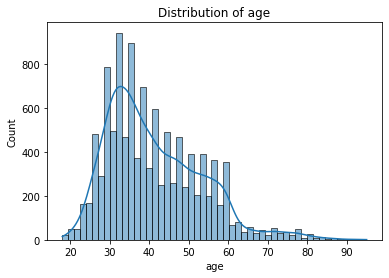

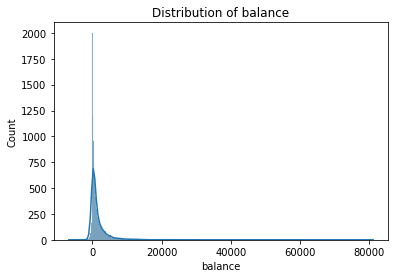

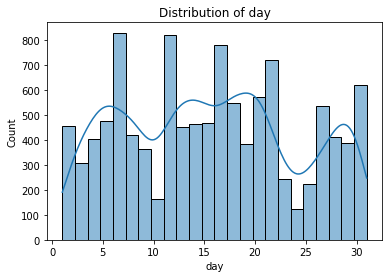

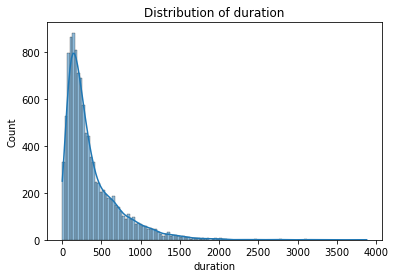

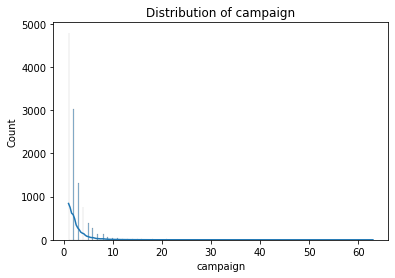

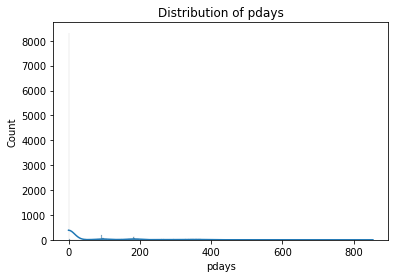

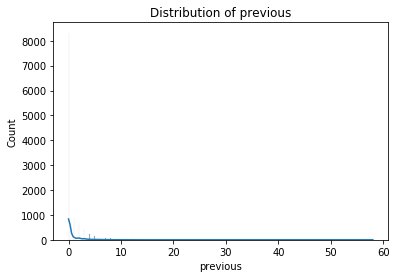

In [14]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [15]:
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'deposit'],
      dtype='object')

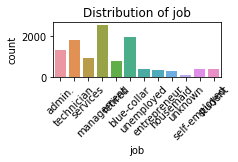

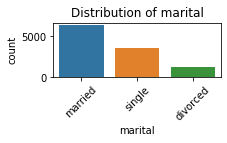

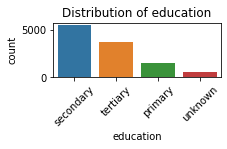

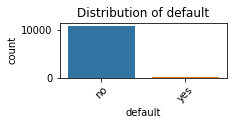

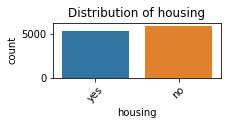

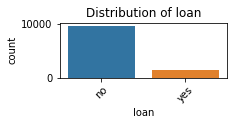

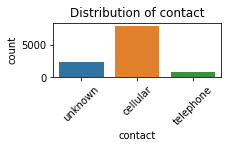

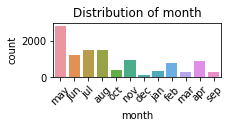

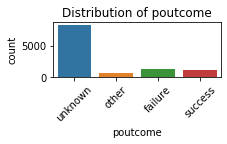

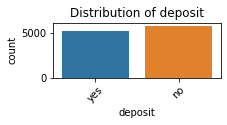

In [19]:
for col in categorical_cols:
    plt.figure(figsize=(3,1))
    sns.countplot(data=df, x=col)

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

    plt.show()

Why use a countplot for categorical variables instead of a histogram?

---> A histogram is designed for numerical continuous variables.

A countplot is designed for categorical variables and shows the frequency of each category.

### Bivariate Analysis

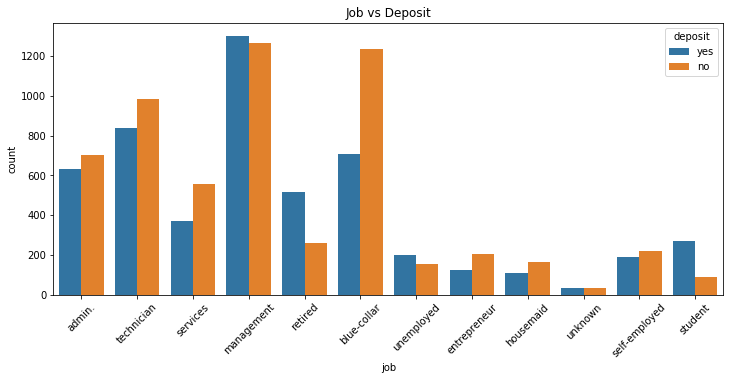

In [22]:
# job vs deposit

plt.figure(figsize=(12,5))

sns.countplot(data=df, x='job', hue='deposit')

plt.xticks(rotation=45)
plt.title("Job vs Deposit")
plt.show()

Management has a large number of both "yes" and "no" customers because there are many management customers overall.
Blue-collar customers tend to have more "no" than "yes."
Retired customers usually have a relatively high proportion of "yes" compared to their total count.
Students also often have a surprisingly good proportion of subscriptions.
Unknown has very few records.

--> Different occupations respond differently to marketing campaign, This helps banks answer questions like:

Which customer segments should we target first?

Instead of calling everyone, they can prioritize occupations with higher subscription rates.

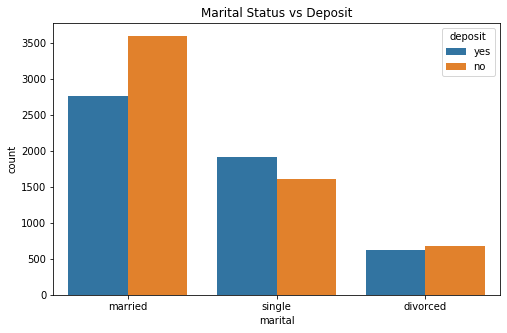

In [23]:
# Marital vs Deposit
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='marital', hue='deposit')

plt.title("Marital Status vs Deposit")

plt.show()

Married customers are the largest group.
Single customers often have a relatively good proportion of subscriptions.
Divorced customers are the smallest group.
The difference between married and single is noticeable but not extreme.

--> Marital status may influence financial decisions, but it is unlikely to be the strongest predictor.

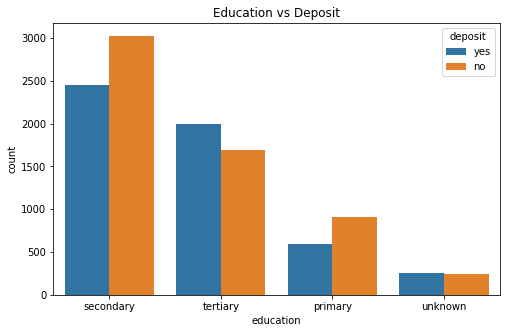

In [24]:
# Education vs Deposit
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='education', hue='deposit')

plt.title("Education vs Deposit")

plt.show()

--> Customers with higher education may be more likely to invest in financial products, but we'll let the model determine the true importance.

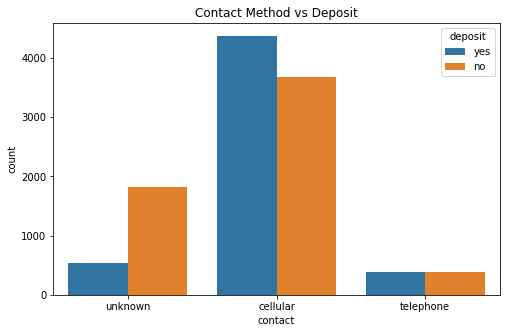

In [25]:
# Contact vs Deposit
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='contact', hue='deposit')

plt.title("Contact Method vs Deposit")

plt.show()

Cellular has the highest number of customers.
Customers contacted via cellular have a noticeably higher number of subscriptions (yes) than those contacted via telephone.
Unknown has more no than yes.

--> Customers contacted through mobile phones appear more responsive than those contacted via landlines.

A bank could prioritize mobile contact in future campaigns.

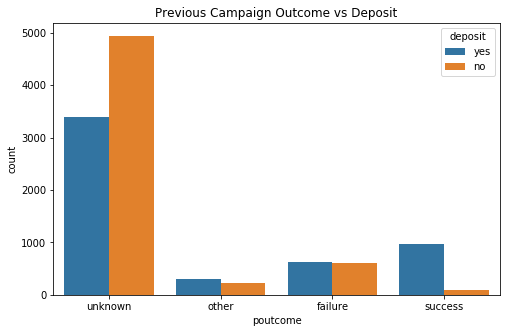

In [26]:
# Previous Campaign Outcome -  poutcome vs deposit
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='poutcome', hue='deposit')

plt.title("Previous Campaign Outcome vs Deposit")

plt.show()

Customers with success in the previous campaign have a much higher proportion of deposit = yes.
Failure has more deposit = no.
Unknown is dominated by deposit = no.

--> A customer who subscribed previously is much more likely to subscribe again.Banks could use this to prioritize customers for future campaigns.

* Why poutcome expected to have high feature importance?

Answer:
Because previous campaign success strongly indicates customer interest in similar financial products, making it highly predictive of future subscriptions.

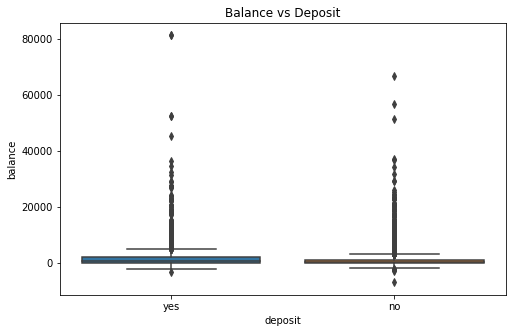

In [27]:
# Balance vs Deposit
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='deposit', y='balance')

plt.title("Balance vs Deposit")

plt.show()

Customers who subscribed (yes) generally have a higher median balance.
There are many outliers in both groups.
The "yes" group tends to have slightly higher balances overall.

--> Customers with larger balances are more likely to invest in a term deposit.

** Why use a boxplot instead of a histogram here?

Answer:
Because we want to compare the distribution of a numerical feature across two target classes. A boxplot makes differences in median, spread, and outliers easy to see.

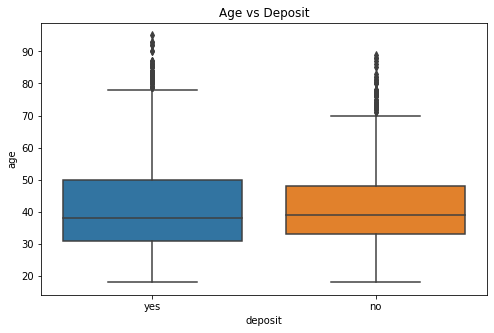

In [28]:
# Age vs Deposit
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='deposit', y='age')

plt.title("Age vs Deposit")

plt.show()

Customers who subscribed tend to be slightly older on average.
There is considerable overlap between the two groups.

--> Older customers may be more interested in low-risk investment products such as term deposits.